# Feature Engineering & Selección de Características — Sentinel-2

**Autores**: Arthur Zizumbo, Aaron Bocanegra, Isaac Ávila  
**Fecha**: 2026-05-17  
**Notebook anterior**: `02a_eda_sentinel2.ipynb`

---

## Objetivo

Transformar las 10 bandas espectrales crudas de Sentinel-2 en un **conjunto de características
listo para entrenamiento**, aplicando las dos fases del pipeline:

**Fase 1 — Ingeniería de características (Feature Engineering)**

| Técnica | Justificación |
|---|---|
| Índices espectrales | Resumen físicamente interpretable de combinaciones de bandas |
| Discretización / Binning | Captura relaciones no lineales; reduce sensibilidad a ruido |
| Transformación (log1p, sqrt, Box-Cox, Yeo-Johnson) | Corrige sesgo positivo documentado en EDA |
| Escalamiento (Min-Max, Z-score, Robust) | Requisito de convergencia para modelos lineales y redes neuronales |
| Codificación (Ordinal, One-Hot) | Convierte variables categóricas en representación numérica compatible |

**Fase 2 — Selección y extracción de características**

| Método | Tipo | Justificación |
|---|---|---|
| Umbral de varianza | Filtrado | Elimina features sin poder discriminativo |
| Correlación de Pearson/Spearman | Filtrado | Detecta redundancia entre features |
| Chi-cuadrado | Filtrado | Mide dependencia feature–clase (variables discretizadas) |
| ANOVA F-score | Filtrado | Separa varianza entre clases vs. dentro de clase |
| PCA | Extracción | Reduce dimensionalidad conservando varianza máxima |
| Análisis Factorial (FA) | Extracción | Identifica factores latentes (grupos de bandas correlacionadas) |

**Decisiones heredadas del EDA**:
- Máscara de calidad (clip P99.5) replicada antes de cualquier operación
- Transformación log1p/Yeo-Johnson para corregir sesgo
- Verano priorizado en ventanas GEE; pérdidas en otoño aceptadas para Pianura Padana
- Las 10 bandas se conservan como features candidatas


## 1. Setup & Configuración

In [1]:
# ── Parámetros configurables ──────────────────────────────────────────────────
sample_size: int  = 100_000   # píxeles totales para sample estratificado
n_patches:   int  = 100       # escenas PASTIS a cargar
use_gee:     bool = True      # descargar muestras GEE Italia
seed:        int  = 42        # reproducibilidad global
N_BINS:      int  = 5         # bins para discretización


In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from __future__ import annotations
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from IPython.display import Markdown, display

from scipy import stats as scipy_stats
from scipy.special import boxcox1p
from sklearn.preprocessing import (
    KBinsDiscretizer,
    LabelEncoder,
    MinMaxScaler,
    PowerTransformer,
    RobustScaler,
    StandardScaler,
)
from sklearn.feature_selection import (
    VarianceThreshold,
    chi2,
    f_classif,
    SelectKBest,
)
from sklearn.decomposition import PCA, FactorAnalysis

# ── repo root ─────────────────────────────────────────────────────────────────
_ROOT = Path.cwd().resolve()
for _c in (_ROOT, *_ROOT.parents):
    if (_c / "pyproject.toml").is_file():
        _ROOT = _c
        break
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

from ml.ingest.pastis_loader import (
    PASTIS_CLASS_MAP,
    PASTIS_S2_BANDS,
    pastis_patch_index,
    pastis_to_polars,
)
from ml.utils.notebook_setup import find_repo_root
from ml.utils.sampling import stratified_sample

ROOT    = find_repo_root()
DATA    = ROOT / "data"
PASTIS  = DATA / "PASTIS-R"
FIG_OUT = ROOT / "paper" / "figures" / "us-020"
FIG_OUT.mkdir(parents=True, exist_ok=True)
EXPORT  = ROOT / "data" / "features"
EXPORT.mkdir(parents=True, exist_ok=True)

pio.renderers.default = "notebook"
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(30)
np.random.seed(seed)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
warnings.filterwarnings("ignore")

ALL_BANDS = PASTIS_S2_BANDS   # 10 bandas — sin descarte univariado
print(f"Bandas candidatas ({len(ALL_BANDS)}): {ALL_BANDS}")
display(Markdown(
    f"### Setup listo\n"
    f"- Repo: `{ROOT}`  ·  PASTIS disponible: `{PASTIS.exists()}`\n"
    f"- Figuras: `{FIG_OUT}`  ·  Export: `{EXPORT}`\n"
    f"- `sample_size={sample_size:,}`  ·  `n_patches={n_patches}`  ·  "
    f"`seed={seed}`  ·  `N_BINS={N_BINS}`"
))


Bandas candidatas (10): ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']


### Setup listo
- Repo: `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot`  ·  PASTIS disponible: `True`
- Figuras: `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\paper\figures\us-020`  ·  Export: `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\data\features`
- `sample_size=100,000`  ·  `n_patches=100`  ·  `seed=42`  ·  `N_BINS=5`

## 2. Carga de Datos + Máscara de Calidad

**Justificación**: La máscara de calidad se aplica **inmediatamente tras la carga**,
antes de cualquier cálculo de índice, transformación o escalado. Esto garantiza que
ninguna feature derivada herede píxeles contaminados por nubes o artefactos de corrección
atmosférica — decisión documentada en el EDA (§3, `02a_eda_sentinel2_v2`).

Pasos:
1. Filtrar NODATA (`value ≤ −1000`, sentinel de PASTIS-R).
2. Clip vectorizado al **P99.5 por banda** (nubes residuales no capturadas por NODATA).
3. GEE Italia: verano priorizado (`n_pixels=3000`), pérdida aceptada en otoño para Pianura Padana.


In [3]:
# ── 2a. Índice de patches PASTIS-R ────────────────────────────────────────────
patch_index = pastis_patch_index(PASTIS / "metadata.geojson")
print(f"Patches disponibles: {patch_index.height:,}")

if patch_index.height > 0:
    sampled_patches = stratified_sample(
        patch_index, by=["TILE", "Fold"], n=n_patches, seed=seed
    )
    patch_ids = sampled_patches["patch_id"].to_list()
    print(f"Patches seleccionados (estratificados TILE×Fold): {len(patch_ids)}")
else:
    patch_ids = []
    print("PASTIS no disponible — modo sintético")


Patches disponibles: 2,433
Patches seleccionados (estratificados TILE×Fold): 91


In [4]:
# ── 2b. Carga long-format + MÁSCARA DE CALIDAD (P99.5 clip vectorizado) ──────
# Justificación del clip P99.5: valores >P99.5 corresponden estadísticamente a
# nubes residuales o superficies muy brillantes (agua con sol especular).
# El clip conserva los píxeles pero limita su influencia en distribuciones y modelos.
# Se usa pl.when/then encadenado — 100% vectorizado, sin Python UDF.

def apply_quality_mask(df: pl.DataFrame, bands: list[str]) -> tuple[pl.DataFrame, dict]:
    """Filtra NODATA y aplica clip P99.5 por banda. Retorna df limpio y umbrales."""
    df = df.filter(pl.col("value") > -1000)
    thresholds = {
        b: float(df.filter(pl.col("band") == b)["value"].quantile(0.995))
        for b in bands
        if b in df["band"].unique().to_list()
    }
    clip_expr = pl.col("value")
    for band, thr in thresholds.items():
        clip_expr = (
            pl.when((pl.col("band") == band) & (pl.col("value") > thr))
            .then(pl.lit(thr))
            .otherwise(clip_expr)
        )
    df = df.with_columns(clip_expr.cast(pl.Float64).alias("value"))
    return df, thresholds

if patch_ids:
    df_raw = pastis_to_polars(patch_ids, root=PASTIS, pixel_stride=4)
    n_raw  = df_raw.height
    print(f"Filas crudas: {n_raw:,}")
    df_pastis, P995 = apply_quality_mask(df_raw, ALL_BANDS)
    pct_drop = 100 * (1 - df_pastis.height / n_raw)
    print(f"Tras máscara:  {df_pastis.height:,}  ({pct_drop:.2f}% descartado)")
else:
    # Modo sintético — distribución lognormal para simular reflectancias reales
    rng  = np.random.default_rng(seed)
    rows = []
    CLASS_IDS   = list(range(1, 19))
    CLASS_NAMES = list(PASTIS_CLASS_MAP.values()) if PASTIS_CLASS_MAP else [f"C{i}" for i in CLASS_IDS]
    for i, band in enumerate(ALL_BANDS):
        vals = rng.lognormal(mean=6.8 + i * 0.12, sigma=0.45, size=3000).clip(max=12_000)
        for v in vals:
            cid = int(rng.choice(CLASS_IDS))
            rows.append({
                "band": band, "value": float(v),
                "class_id": cid,
                "class_name": CLASS_NAMES[cid - 1] if cid <= len(CLASS_NAMES) else f"C{cid}",
                "date": int(rng.choice([20190615, 20190715, 20190815])),
            })
    df_pastis, P995 = apply_quality_mask(pl.DataFrame(rows), ALL_BANDS)
    print(f"Modo sintético — {df_pastis.height:,} filas tras máscara")

print("\nUmbrales P99.5 por banda:")
for b, v in P995.items():
    print(f"  {b}: {v:,.0f}")
display(df_pastis.head(5))


Filas crudas: 44,062,720
Tras máscara:  43,856,626  (0.47% descartado)

Umbrales P99.5 por banda:
  B02: 9,745
  B03: 9,739
  B04: 10,103
  B05: 10,114
  B06: 10,279
  B07: 10,321
  B08: 10,371
  B8A: 10,439
  B11: 7,407
  B12: 5,978


patch_id,t,date,y,x,band,value,class_id,fold,class_name
str,i64,i64,i64,i64,str,f64,i16,i64,str
"""10430""",0,20180924,0,0,"""B02""",5884.0,19,1,"""Void label"""
"""10430""",0,20180924,0,4,"""B02""",7420.0,19,1,"""Void label"""
"""10430""",0,20180924,0,8,"""B02""",9745.0,19,1,"""Void label"""
"""10430""",0,20180924,0,12,"""B02""",8911.0,1,1,"""Meadow"""
"""10430""",0,20180924,0,16,"""B02""",8385.0,1,1,"""Meadow"""


In [5]:
# ── 2c. GEE Italia — verano priorizado, pérdida aceptada en otoño ─────────────
# Justificación: el análisis SCL del EDA muestra que verano tiene la menor
# nubosidad en las 3 ROIs (~11-33%). Otoño en Pianura Padana pierde ~53% de
# píxeles — se acepta este déficit en lugar de usar compósitos de menor calidad.
df_gee = pl.DataFrame()
if use_gee:
    import time
    from ml.utils.notebook_setup import configure_ee_from_env
    gee_project, sa_json = configure_ee_from_env(ROOT)
    try:
        import ee
        from ml.ingest.gee_sampler import init_ee, sample_s2_roi
        init_ee(service_account_json=sa_json, project=gee_project)
        roi_defs = {
            "pianura_padana": [10.0, 45.0, 11.0, 45.5],
            "toscana":        [11.0, 43.5, 12.0, 44.0],
            "apulia":         [16.0, 41.0, 17.0, 41.5],
        }
        # Orden refleja prioridad de calidad; n_pixels diferenciado por estación
        seasons = [
            ("2023-06-01", "2023-08-31", "summer", 3000),  # PRIORITARIO
            ("2023-03-01", "2023-05-31", "spring", 2000),
            ("2023-09-01", "2023-11-30", "autumn", 2000),  # pérdida aceptada
        ]
        frames, idx = [], 0
        for name, bbox in roi_defs.items():
            geom = ee.Geometry.BBox(*bbox)
            for s_start, s_end, season, n_px in seasons:
                idx += 1
                if name == "pianura_padana" and season == "autumn":
                    print(f"  ⚠  [{idx}] {name} otoño: ~53% inválido esperado — pérdida aceptada")
                try:
                    d = sample_s2_roi(geom, start_date=s_start, end_date=s_end,
                                      n_pixels=n_px, roi_name=name,
                                      cache_path=ROOT/"data"/"cache"/"gee")
                    if not d.is_empty():
                        d, _ = apply_quality_mask(
                            d.with_columns(pl.lit(season).alias("season")), ALL_BANDS
                        )
                        frames.append(d)
                        print(f"  ✓  [{idx}] {name:18s} {season:8s} n_px={n_px} → {d.height:,} px")
                    else:
                        print(f"  –  [{idx}] {name:18s} {season:8s} → vacío")
                except Exception as e:
                    print(f"  ✗  [{idx}] {name:18s} {season:8s} → {type(e).__name__}: {e}")
        if frames:
            df_gee = pl.concat(frames, how="vertical_relaxed")
            print(f"\nGEE total: {df_gee.height:,} filas")
            display(df_gee.group_by("season").agg(pl.len().alias("n")).sort("season"))
    except Exception as exc:
        print(f"GEE no disponible: {exc}")
else:
    print("use_gee=False — se omite GEE")


  ✓  [1] pianura_padana     summer   n_px=3000 → 30,000 px
  ✓  [2] pianura_padana     spring   n_px=2000 → 20,000 px
  ⚠  [3] pianura_padana otoño: ~53% inválido esperado — pérdida aceptada
  ✓  [3] pianura_padana     autumn   n_px=2000 → 20,000 px
  ✓  [4] toscana            summer   n_px=3000 → 30,000 px
  ✓  [5] toscana            spring   n_px=2000 → 20,000 px
  ✓  [6] toscana            autumn   n_px=2000 → 20,000 px
  ✓  [7] apulia             summer   n_px=3000 → 30,000 px
  ✓  [8] apulia             spring   n_px=2000 → 20,000 px
  ✓  [9] apulia             autumn   n_px=2000 → 20,000 px

GEE total: 210,000 filas


season,n
str,u32
"""autumn""",60000
"""spring""",60000
"""summer""",90000


In [6]:
# ── 2d. Sample estratificado + pivot a formato WIDE (1 fila = 1 píxel) ────────
# Formato wide necesario para: índices espectrales, scalers, transformers sklearn.
# Formato: columnas = bandas; filas = píxeles.

if "class_id" in df_pastis.columns and df_pastis.height > sample_size:
    df_sample = stratified_sample(df_pastis, by=["band", "class_id"], n=sample_size, seed=seed)
else:
    df_sample = df_pastis

id_cols   = [c for c in ["class_id", "class_name", "date"] if c in df_sample.columns]
df_wide   = (
    df_sample
    .pivot(on="band", index=id_cols, values="value", aggregate_function="mean")
    .rename({b: f"B_{b}" for b in ALL_BANDS if b in df_sample["band"].unique()})
)
band_cols = [f"B_{b}" for b in ALL_BANDS if f"B_{b}" in df_wide.columns]
print(f"Formato wide: {df_wide.shape}  |  Columnas de banda: {band_cols}")
display(df_wide.head(5))


Formato wide: (1618, 13)  |  Columnas de banda: ['B_B02', 'B_B03', 'B_B04', 'B_B05', 'B_B06', 'B_B07', 'B_B08', 'B_B8A', 'B_B11', 'B_B12']


class_id,class_name,date,B_B02,B_B03,B_B04,B_B05,B_B06,B_B07,B_B08,B_B11,B_B12,B_B8A
i16,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""Background""",20190319,1662.806452,669.111111,1574.115385,1758.16,2619.84,3116.28,2919.666667,2935.913043,2082.521739,3877.73913
0,"""Background""",20190808,425.568182,748.608696,685.787879,1045.294118,2233.74359,2684.973684,2854.4,2239.162162,1403.675676,3099.324324
0,"""Background""",20190922,2344.833333,2493.421053,2659.95,2857.2,3036.0,3766.444444,3842.894737,2971.944444,2174.777778,3804.5
0,"""Background""",20190831,286.6,468.12,341.166667,712.521739,2197.846154,2919.75,2777.518519,2063.142857,1165.035714,3235.464286
0,"""Background""",20190222,364.411765,555.952381,739.352941,819.823529,1607.5,1786.466667,2087.071429,1885.4,1186.2,2453.6


## 3. Generación de Nuevas Características — Índices Espectrales

**Justificación**: Los índices espectrales son combinaciones de bandas con significado
físico documentado. Condensan la información de múltiples bandas en una sola métrica
interpretable, reduciendo el espacio de hipótesis del modelo sin perder información
discriminativa.

| Índice | Fórmula | Interpreta |
|---|---|---|
| NDVI | (NIR − R) / (NIR + R) | Vigor vegetativo (−1 a +1) |
| NDWI | (G − NIR) / (G + NIR) | Contenido de agua en vegetación |
| EVI | 2.5 × (NIR − R) / (NIR + 6R − 7.5B + 1) | NDVI mejorado, menos saturación |
| NDRE | (NIR − RE1) / (NIR + RE1) | Clorofila en vegetación densa |
| SAVI | 1.5 × (NIR − R) / (NIR + R + 0.5) | NDVI corregido por suelo desnudo |
| MSI | SWIR1 / NIR | Estrés hídrico de la hoja |
| BSI | ((SWIR1 + R) − (NIR + B)) / ((SWIR1 + R) + (NIR + B)) | Suelo desnudo |
| NBR | (NIR − SWIR2) / (NIR + SWIR2) | Quemas / cicatrices |


In [7]:
# ── 3a. Cálculo de índices espectrales ────────────────────────────────────────
# Sentinel-2 mapping: B02=Blue, B03=Green, B04=Red, B05=RE1, B06=RE2,
#                     B07=RE3, B08=NIR, B8A=NIR_narrow, B11=SWIR1, B12=SWIR2
eps = 1e-6  # evita división por cero

def safe_idx(a, b):
    """Índice normalizado genérico con protección numérica."""
    return (a - b) / (a + b + eps)

df_idx = df_wide.clone()

# Extraer arrays numpy para operar vectorialmente
B  = df_idx["B_B02"].to_numpy().astype(float)
G  = df_idx["B_B03"].to_numpy().astype(float)
R  = df_idx["B_B04"].to_numpy().astype(float)
RE1= df_idx["B_B05"].to_numpy().astype(float)
NIR= df_idx["B_B08"].to_numpy().astype(float)
SW1= df_idx["B_B11"].to_numpy().astype(float)
SW2= df_idx["B_B12"].to_numpy().astype(float)

ndvi  = safe_idx(NIR, R)
ndwi  = safe_idx(G,   NIR)
evi   = 2.5 * (NIR - R) / (NIR + 6*R - 7.5*B + 1 + eps)
ndre  = safe_idx(NIR, RE1)
savi  = 1.5 * (NIR - R) / (NIR + R + 0.5 + eps)
msi   = SW1 / (NIR + eps)
bsi   = ((SW1 + R) - (NIR + B)) / ((SW1 + R) + (NIR + B) + eps)
nbr   = safe_idx(NIR, SW2)

index_arrays = {
    "idx_NDVI": ndvi, "idx_NDWI": ndwi, "idx_EVI": evi,
    "idx_NDRE": ndre, "idx_SAVI": savi, "idx_MSI":  msi,
    "idx_BSI":  bsi,  "idx_NBR":  nbr,
}

for name, arr in index_arrays.items():
    df_idx = df_idx.with_columns(pl.Series(name, arr.astype(float)))

index_cols = list(index_arrays.keys())

# ==============================================================================
# FILTRADO DE INF / NAN ANTES DEL DESCRIBE Y BINNING
# ==============================================================================
for c in index_cols:
    # 1. Filtramos los valores válidos en una Serie temporal para calcular una mediana real
    clean_series = df_idx.select(pl.col(c)).filter(
        (~pl.col(c).is_nan()) & (~pl.col(c).is_infinite())
    )[c]
    
    # Si la columna está totalmente corrupta ponemos 0.0, si no, calculamos su mediana
    col_median = clean_series.median() if len(clean_series) > 0 else 0.0
    if col_median is None: 
        col_median = 0.0

    # 2. Reemplazamos los NaN e Infinitos por la mediana limpia directamente en Polars
    df_idx = df_idx.with_columns(
        pl.when(pl.col(c).is_nan() | pl.col(c).is_infinite())
        .then(col_median)
        .otherwise(pl.col(c))
        .alias(c)
    )

print(f"Índices generados ({len(index_cols)}): {index_cols}")
print(f"Shape tras índices: {df_idx.shape}")
display(df_idx.select(index_cols).describe())


Índices generados (8): ['idx_NDVI', 'idx_NDWI', 'idx_EVI', 'idx_NDRE', 'idx_SAVI', 'idx_MSI', 'idx_BSI', 'idx_NBR']
Shape tras índices: (1618, 21)


statistic,idx_NDVI,idx_NDWI,idx_EVI,idx_NDRE,idx_SAVI,idx_MSI,idx_BSI,idx_NBR
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1618.0,1618.0,1618.0,1618.0,1618.0,1618.0,1618.0,1618.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.425442,-0.454781,1.35307,0.311713,0.638079,0.816151,-0.057648,0.314611
"""std""",0.253667,0.216613,27.925353,0.191073,0.380444,0.373445,0.169734,0.209402
"""min""",-0.6424,-1.028445,-288.651266,-0.649012,-0.963536,0.045243,-0.73559,-0.724566
"""25%""",0.241676,-0.610731,0.428346,0.176823,0.362473,0.62638,-0.14257,0.184278
"""50%""",0.409419,-0.477114,0.938074,0.306587,0.614049,0.781638,-0.047572,0.310892
"""75%""",0.600245,-0.325755,1.609441,0.435618,0.900243,0.963158,0.048739,0.44029
"""max""",1.705327,0.551026,1075.794144,0.944792,2.556267,9.373874,0.630956,0.955334


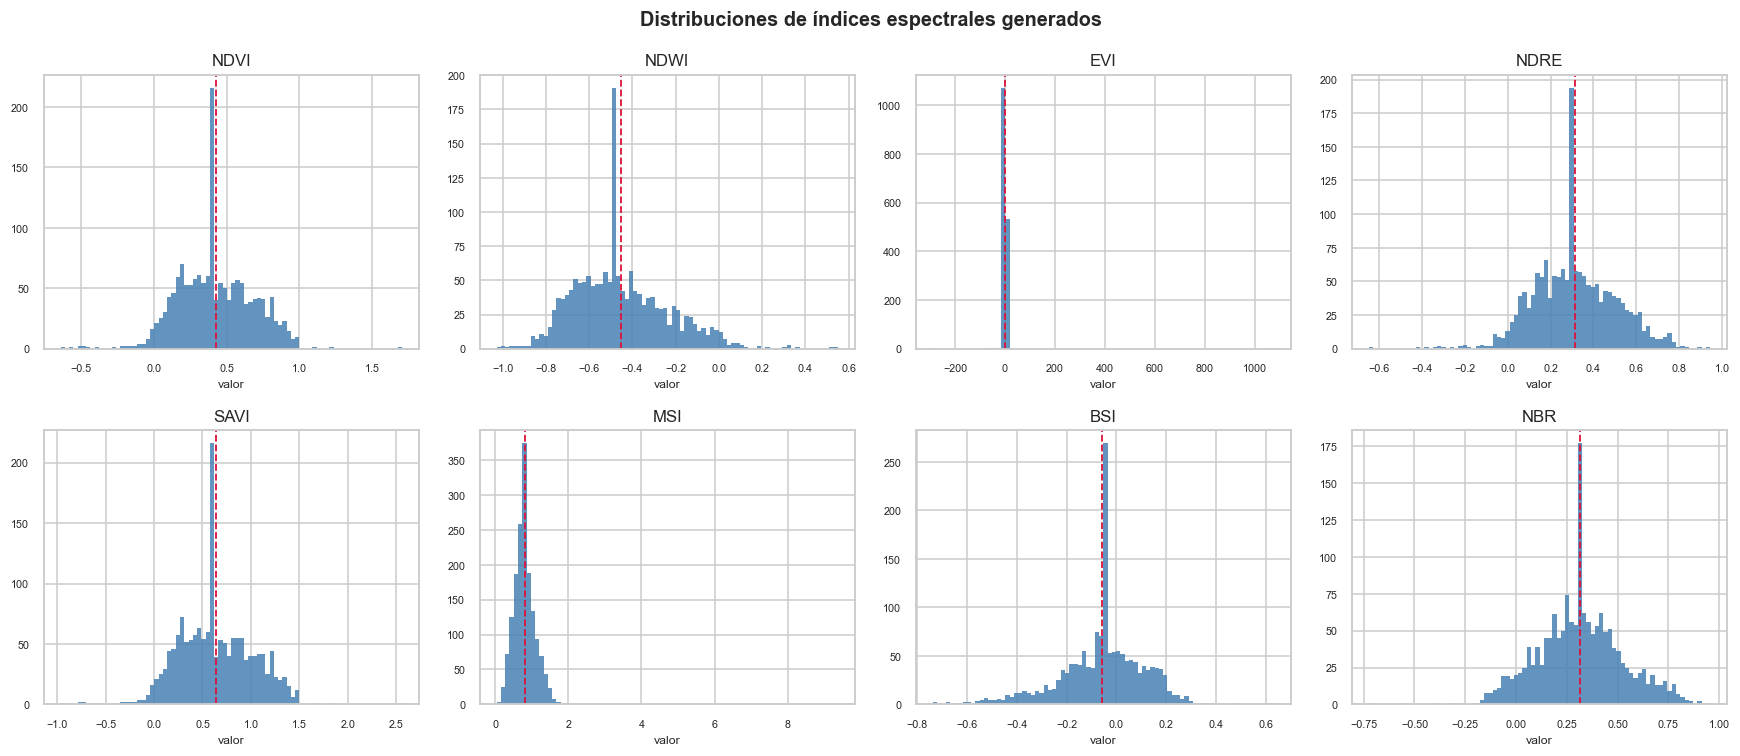

Figura guardada: C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\paper\figures\us-020\fe_01_spectral_indices.png


In [8]:
# ── 3b. Visualización de índices (distribuciones por clase) ───────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), index_cols):
    df_plot = df_idx.select([col, "class_name"]).to_pandas() if "class_name" in df_idx.columns else df_idx.select([col]).to_pandas()
    ax.hist(df_idx[col].to_numpy(), bins=80, color="steelblue", edgecolor="none", alpha=0.85)
    ax.set_title(col.replace("idx_", ""), fontsize=11)
    ax.set_xlabel("valor", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.axvline(float(df_idx[col].mean()), color="crimson", lw=1.2, ls="--", label="media")

fig.suptitle("Distribuciones de índices espectrales generados", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_OUT / "fe_01_spectral_indices.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {FIG_OUT / 'fe_01_spectral_indices.png'}")


## 4. Discretización / Binning

**Justificación**: El binning convierte variables continuas en categorías ordinales,
lo que permite a los modelos capturar relaciones no lineales que la escala continua
podría ocultar. Es especialmente útil para:

- **NDVI**: los umbrales estándar (-0.1, 0.2, 0.5) corresponden a clases físicas conocidas
  (agua/suelo/vegetación escasa/vegetación densa), alineando las bins con el conocimiento del dominio.
- **Bandas brutas**: quantile binning es agnóstico de dominio y asegura bins equipoblados,
  útil para chi-cuadrado (§7.3) que requiere frecuencias esperadas > 5.

Se aplican dos estrategias:
- **Quantile** (equipoblado): para variables sin umbrales de dominio conocidos.
- **Kmeans**: para variables donde la distribución presenta agrupamientos naturales (e.g. NDVI).


In [9]:
# ── 4a. Binning cuantil sobre las 10 bandas brutas ───────────────────────────

# 1. Convertir las columnas Polars seleccionadas a un DataFrame de pandas
#X_bands = df_idx.select(band_cols).to_pandas()

# 1. Convertir a pandas después de llenar los nulls con la mediana en Polars — evita problemas de NaN en sklearn
X_bands = (
    df_idx.select(band_cols)
    .with_columns([
        pl.col(c).fill_null(pl.col(c).median()) for c in band_cols
    ])
    .to_pandas()
)


# 2. Inicializacion y "fit" del discretizador
kbd_quantile = KBinsDiscretizer(n_bins=N_BINS, encode="ordinal", strategy="quantile")
X_binned_q   = kbd_quantile.fit_transform(X_bands)

bin_q_cols = [f"bin_q_{c}" for c in band_cols]
df_binned  = df_idx.clone()
for j, col in enumerate(bin_q_cols):
    df_binned = df_binned.with_columns(
        pl.Series(col, X_binned_q[:, j].astype(int))
    )

# ── 4b. Binning NDVI con umbrales de dominio ─────────────────────────────────
ndvi_breaks = [-1.0, -0.1, 0.2, 0.5, 1.0]
ndvi_labels = [0, 1, 2, 3]   # agua/sombra, suelo desnudo, veg.escasa, veg.densa
ndvi_bin_arr = np.digitize(df_binned["idx_NDVI"].to_numpy(), bins=ndvi_breaks[1:-1])
df_binned = df_binned.with_columns(pl.Series("bin_ndvi_domain", ndvi_bin_arr.astype(int)))

# ── 4c. Binning kmeans sobre EVI ──────────────────────────────────────────────
kbd_km = KBinsDiscretizer(n_bins=N_BINS, encode="ordinal", strategy="kmeans")

evi_bin_arr = kbd_km.fit_transform(df_idx.select("idx_EVI").to_pandas()).flatten()
df_binned = df_binned.with_columns(pl.Series("bin_evi_kmeans", evi_bin_arr.astype(int)))

bin_cols_all = bin_q_cols + ["bin_ndvi_domain", "bin_evi_kmeans"]
print(f"Columnas de binning ({len(bin_cols_all)}): {bin_cols_all[:6]}...")
print(f"Shape: {df_binned.shape}")
display(df_binned.select(["bin_ndvi_domain", "bin_evi_kmeans"] + bin_q_cols[:3]).head(8))


Columnas de binning (12): ['bin_q_B_B02', 'bin_q_B_B03', 'bin_q_B_B04', 'bin_q_B_B05', 'bin_q_B_B06', 'bin_q_B_B07']...
Shape: (1618, 33)


bin_ndvi_domain,bin_evi_kmeans,bin_q_B_B02,bin_q_B_B03,bin_q_B_B04
i64,i64,i64,i64,i64
2,2,4,1,3
3,3,1,1,1
1,3,4,4,4
3,3,0,0,0
2,3,0,0,1
2,3,4,4,4
2,3,4,4,4
1,3,4,4,4


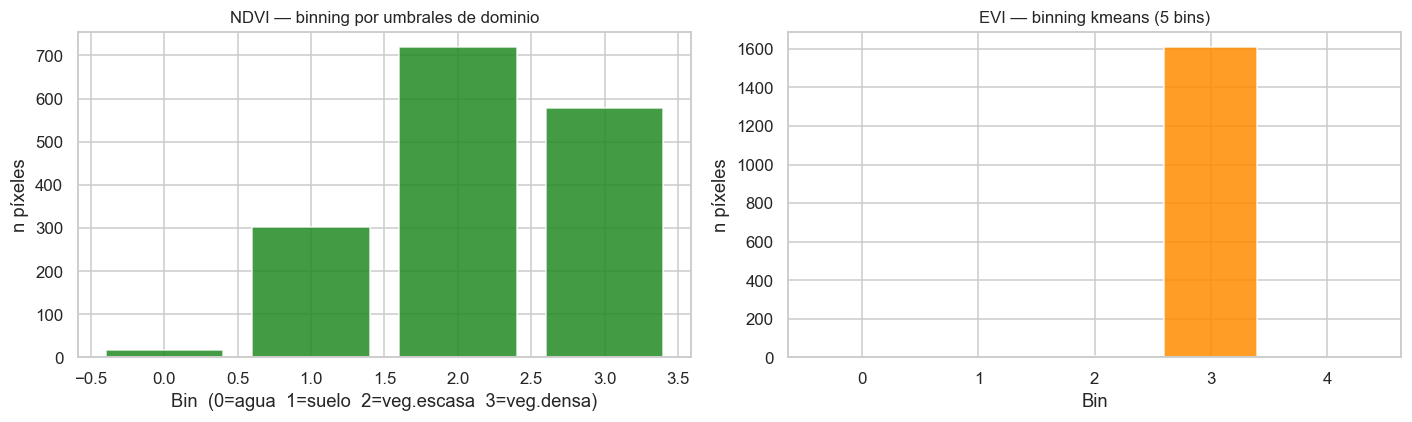

In [10]:
# ── 4d. Visualización: distribución de bins NDVI (dominio) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Frecuencia de bins por estrategia
counts_dom  = df_binned["bin_ndvi_domain"].value_counts().sort("bin_ndvi_domain").to_pandas()
axes[0].bar(counts_dom["bin_ndvi_domain"], counts_dom["count"], color="forestgreen", alpha=0.85)
axes[0].set_title("NDVI — binning por umbrales de dominio", fontsize=11)
axes[0].set_xlabel("Bin  (0=agua  1=suelo  2=veg.escasa  3=veg.densa)")
axes[0].set_ylabel("n píxeles")

counts_km = df_binned["bin_evi_kmeans"].value_counts().sort("bin_evi_kmeans").to_pandas()
axes[1].bar(counts_km["bin_evi_kmeans"], counts_km["count"], color="darkorange", alpha=0.85)
axes[1].set_title(f"EVI — binning kmeans ({N_BINS} bins)", fontsize=11)
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("n píxeles")

fig.tight_layout()
fig.savefig(FIG_OUT / "fe_02_binning.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Transformaciones para Corrección de Sesgo

**Justificación**: El EDA mostró que **ninguna banda pasa Shapiro-Wilk** (alpha=0.01):
todas presentan sesgo positivo pronunciado. Las distribuciones asimétricas penalizan
a los modelos basados en distancias (KNN, SVM radial) y a los métodos lineales (regresión
logística, LDA). Se comparan cuatro transformaciones:

| Transformación | Supuesto | Limitación |
|---|---|---|
| **log1p** | Valores ≥ 0; sesgo moderado-alto | Falla con valores negativos |
| **sqrt** | Valores ≥ 0; sesgo moderado | Menos agresiva que log |
| **Box-Cox** | Valores > 0 estrictamente | No maneja ceros ni negativos |
| **Yeo-Johnson** | Cualquier signo | Default para bandas con negativos (artefactos SCL) |

**Regla de selección automática**: si `min(banda) > 0` → log1p; si no → Yeo-Johnson.
Box-Cox y sqrt se aplican sobre bandas sin negativos como análisis comparativo.


In [11]:
# ── 5a. Transformación automática por banda (log1p vs Yeo-Johnson) ─────────────
# Limpiar NaN/Null in los 10 bandas "crudas" antes de pasarlo a NumPy
df_clean_bands = df_idx.select(band_cols).with_columns([
    pl.when(pl.col(c).is_nan() | pl.col(c).is_null())
    .then(pl.col(c).median())
    .otherwise(pl.col(c))
    .alias(c)
    for c in band_cols
])

#X_bands_np = df_idx.select(band_cols).to_numpy().astype(float)
X_bands_np = df_clean_bands.to_numpy().astype(float)

transform_records = []
X_transformed     = np.empty_like(X_bands_np)

for j, col in enumerate(band_cols):
    vals = X_bands_np[:, j]
    vmin = vals.min()

    if vmin > 0:
        t_vals   = np.log1p(vals)
        method   = "log1p"
        pt       = None
    else:
        pt = PowerTransformer(method="yeo-johnson", standardize=False)
        t_vals   = pt.fit_transform(vals.reshape(-1, 1)).flatten()
        method   = "yeo-johnson"

    X_transformed[:, j] = t_vals
    transform_records.append({
        "banda":   col,
        "método":  method,
        "min_orig": round(float(vmin), 1),
        "skew_orig": round(float(scipy_stats.skew(vals)), 3),
        "skew_post": round(float(scipy_stats.skew(t_vals)), 3),
    })

df_transform_meta = pd.DataFrame(transform_records)
print("Resumen de transformaciones aplicadas:")
display(df_transform_meta)

# Agregar al DataFrame
trans_cols = [f"tf_{c}" for c in band_cols]
df_fe = df_binned.clone()
for j, col in enumerate(trans_cols):
    df_fe = df_fe.with_columns(pl.Series(col, X_transformed[:, j]))

print(f"\nShape tras transformaciones: {df_fe.shape}")


Resumen de transformaciones aplicadas:


,banda,método,min_orig,skew_orig,skew_post
0,B_B02,yeo-johnson,-718.0,2.814,1.163
1,B_B03,yeo-johnson,-66.0,2.645,0.856
2,B_B04,yeo-johnson,-490.0,2.452,1.223
3,B_B05,log1p,101.0,2.484,0.384
4,B_B06,log1p,181.0,2.020,-0.114
5,B_B07,log1p,95.0,1.561,-0.771
6,B_B08,log1p,222.0,1.423,-0.713
7,B_B8A,log1p,513.0,1.372,-0.549
8,B_B11,log1p,204.0,1.177,-0.802
9,B_B12,log1p,92.0,1.153,-0.630



Shape tras transformaciones: (1618, 43)


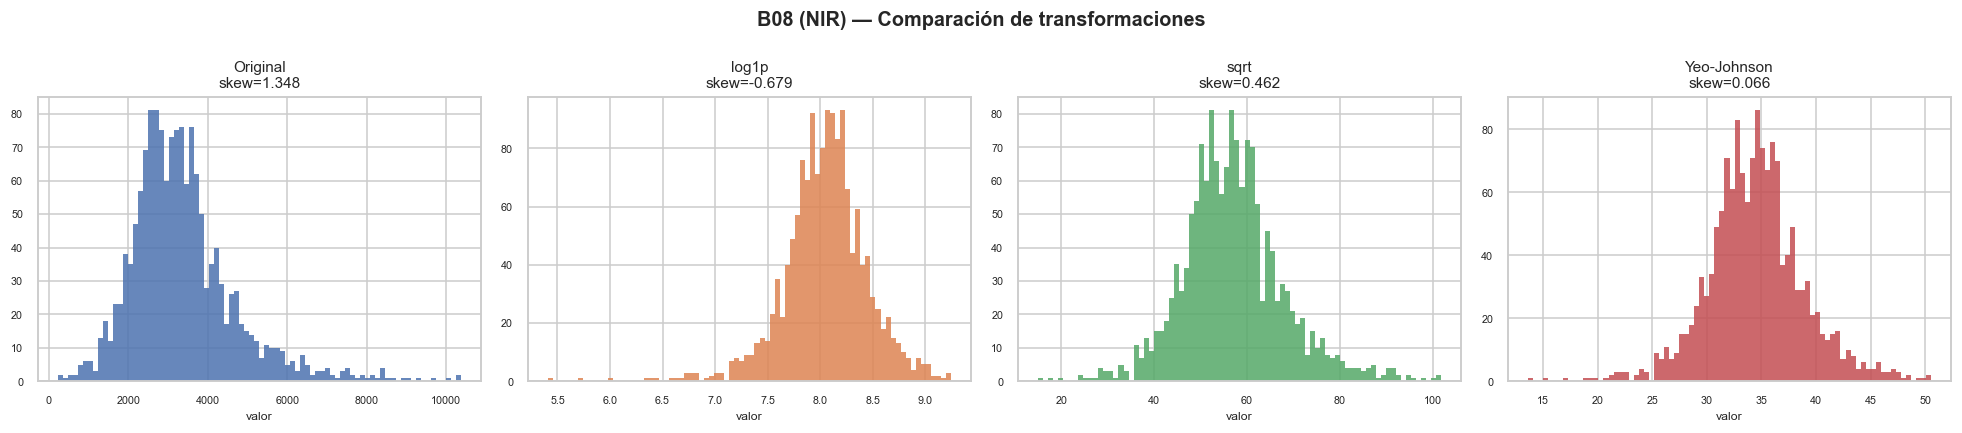

In [12]:
# ── 5b. Análisis comparativo de transformaciones (B08 NIR como ejemplo) ───────
# B08 NIR es la banda con mayor sesgo y la más informativa para vegetación.
# Se muestran las 4 transformaciones para justificar la selección.
nir_col = "B_B08"
nir_vals = df_idx[nir_col].to_numpy().astype(float)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
plot_data = {
    "Original": nir_vals,
    "log1p":    np.log1p(nir_vals),
    "sqrt":     np.sqrt(np.clip(nir_vals, 0, None)),
    "Yeo-Johnson": PowerTransformer(method="yeo-johnson", standardize=False)
                    .fit_transform(nir_vals.reshape(-1, 1)).flatten(),
}

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
for ax, (title, data), color in zip(axes, plot_data.items(), colors):
    sk = scipy_stats.skew(data, nan_policy='omit')
    ax.hist(data, bins=80, color=color, alpha=0.85, edgecolor="none")
    ax.set_title(f"{title}\nskew={sk:.3f}", fontsize=10)
    ax.set_xlabel("valor", fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle("B08 (NIR) — Comparación de transformaciones", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_OUT / "fe_03_transforms_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


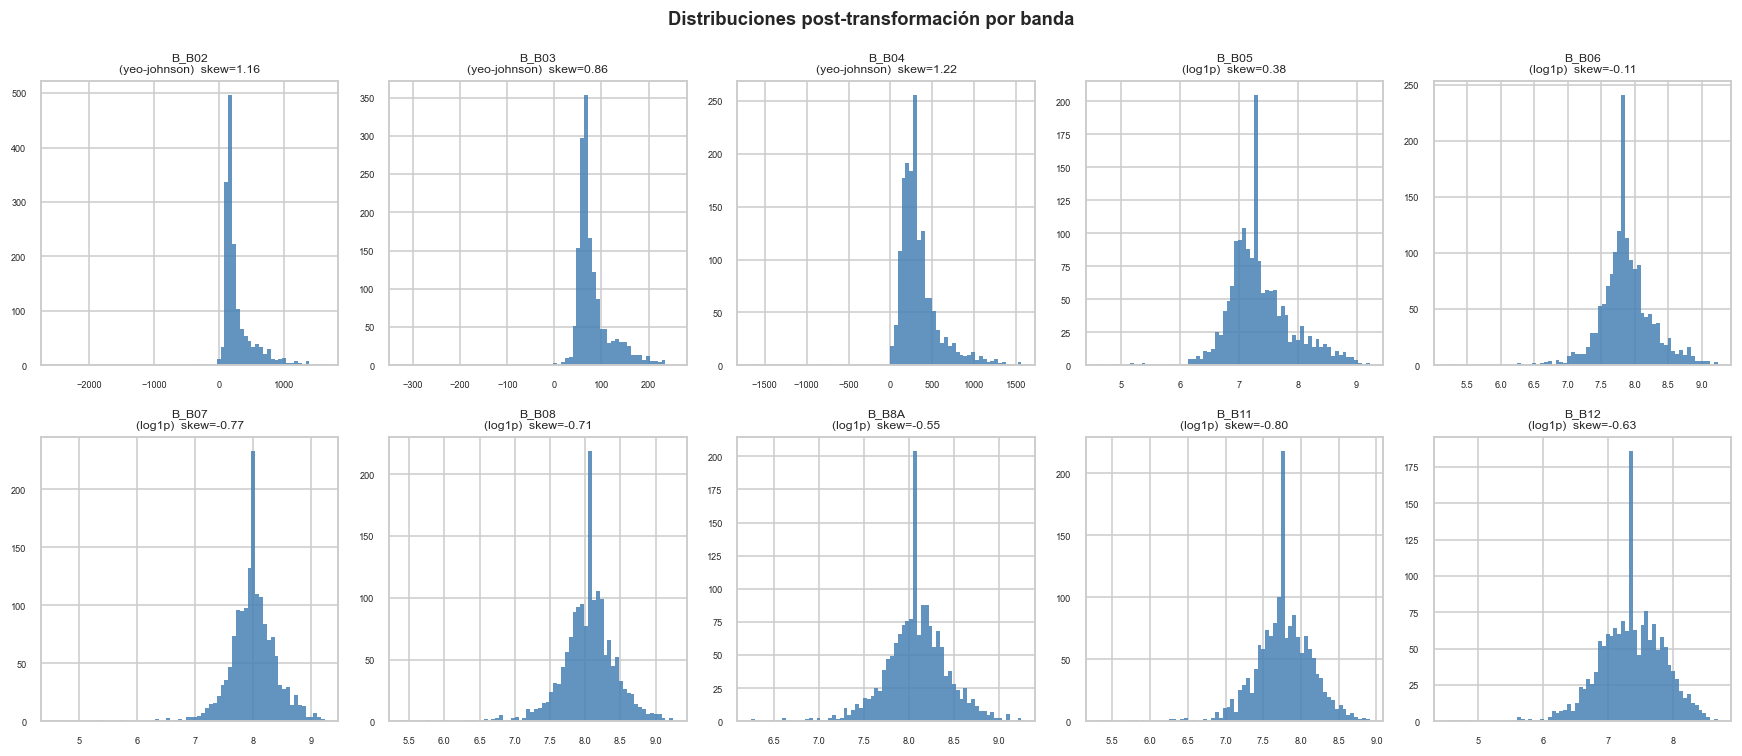

In [13]:
# ── 5c. Distribuciones post-transformación para las 10 bandas ────────────────
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, (col, tc) in zip(axes.flatten(), zip(band_cols, trans_cols)):
    meta = df_transform_meta[df_transform_meta["banda"] == col].iloc[0]
    ax.hist(df_fe[tc].to_numpy(), bins=70, color="steelblue", edgecolor="none", alpha=0.85)
    ax.set_title(f"{col}\n({meta['método']})  skew={meta['skew_post']:.2f}", fontsize=8)
    ax.tick_params(labelsize=6)

fig.suptitle("Distribuciones post-transformación por banda", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_OUT / "fe_04_transforms_all_bands.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Escalamiento

**Justificación**: Las bandas Sentinel-2 tienen rangos de magnitud muy diferentes
(visible ~1,200–1,400 vs NIR ~3,100–3,400). Sin escalado, los modelos basados en
distancias o gradiente asignan más peso implícitamente a las bandas de mayor magnitud.

| Método | Fórmula | Cuándo usarlo |
|---|---|---|
| **Min-Max** | (x − min) / (max − min) → [0,1] | Redes neuronales, visualización |
| **Z-score (Estándar)** | (x − μ) / σ | Regresión, SVM, PCA |
| **Robust** | (x − mediana) / IQR | Datos con outliers moderados (pre-clip) |

Se escalan las **features transformadas** (`tf_*`), no los valores crudos,
para que el escalador opere sobre distribuciones más simétricas.


In [14]:
# ── 6a. Aplicar los tres escaladores sobre las features transformadas ─────────
X_tf = df_fe.select(trans_cols).to_numpy().astype(float)

scalers = {
    "minmax":  MinMaxScaler(),
    "zscore":  StandardScaler(),
    "robust":  RobustScaler(),
}

scaled_dfs = {}
for name, scaler in scalers.items():
    X_sc  = scaler.fit_transform(X_tf)
    cols_ = [f"sc_{name}_{c.replace('tf_B_', '')}" for c in trans_cols]
    # Guardar como pandas para comparación; polars para el DF final
    scaled_dfs[name] = pd.DataFrame(X_sc, columns=cols_)
    print(f"{name:8s} → media global={X_sc.mean():.4f}  std={X_sc.std():.4f}  "
          f"min={X_sc.min():.3f}  max={X_sc.max():.3f}")

# Agregar al df_fe el escalado Z-score (default para modelos lineales/PCA)
zscore_cols = [f"sc_zscore_{c.replace('tf_B_', '')}" for c in trans_cols]
for j, col in enumerate(zscore_cols):
    df_fe = df_fe.with_columns(
        pl.Series(col, scaled_dfs["zscore"].iloc[:, j].to_numpy())
    )

print(f"\nShape tras escalamiento: {df_fe.shape}")


minmax   → media global=0.6655  std=0.1068  min=0.000  max=1.000
zscore   → media global=0.0000  std=1.0000  min=-10.806  max=5.147
robust   → media global=0.1303  std=1.0711  min=-15.709  max=8.218

Shape tras escalamiento: (1618, 53)


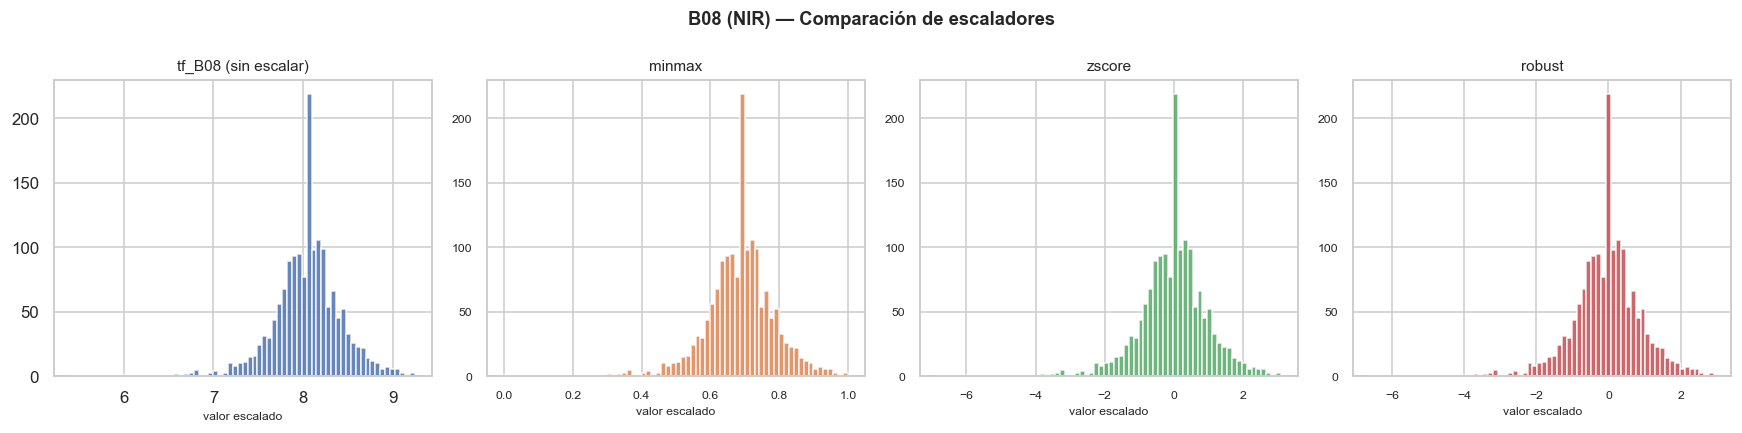

In [15]:
# ── 6b. Comparación visual de escaladores (B08 NIR) ──────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original transformado
axes[0].hist(df_fe["tf_B_B08"].to_numpy(), bins=70, color="#4C72B0", alpha=0.85)
axes[0].set_title("tf_B08 (sin escalar)", fontsize=10)

color_map = {"minmax": "#DD8452", "zscore": "#55A868", "robust": "#C44E52"}
for ax, (sc_name, sc_df) in zip(axes[1:], scaled_dfs.items()):
    # Columna B08 en cada escalador
    col = [c for c in sc_df.columns if "B08" in c][0]
    ax.hist(sc_df[col].to_numpy(), bins=70, color=color_map[sc_name], alpha=0.85)
    ax.set_title(f"{sc_name}", fontsize=10)
    ax.tick_params(labelsize=8)

for ax in axes:
    ax.set_xlabel("valor escalado", fontsize=8)

fig.suptitle("B08 (NIR) — Comparación de escaladores", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_OUT / "fe_05_scaling_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## 7. Codificación de Variables Categóricas

**Justificación**: Los modelos de ML requieren entradas numéricas. Las variables
categóricas del dataset (tipo de cultivo, estación, ROI) deben codificarse.

| Técnica | Cuándo aplicar | Resultado |
|---|---|---|
| **Ordinal** | Variable con orden natural (estación, nivel de vegetación) | Entero 0…K-1 |
| **One-Hot** | Variable nominal sin orden (tipo de cultivo, ROI) | K columnas binarias |

- `class_name` (tipo de cultivo): **One-Hot** — no hay orden natural entre cultivos.
- `bin_ndvi_domain` (nivel de vegetación): ya es ordinal por construcción (§4).
- `season` (si está disponible desde GEE): **Ordinal** (spring=0, summer=1, autumn=2).


In [16]:
# ── 7a. Codificación Ordinal — estaciones ─────────────────────────────────────
# Justificación: spring < summer < autumn tiene un orden fenológico real.
season_order = {"spring": 0, "summer": 1, "autumn": 2}

if "season" in df_fe.columns:
    df_fe = df_fe.with_columns(
        pl.col("season").replace(season_order).cast(pl.Int32).alias("enc_season_ordinal")
    )
    print("✓ Codificación ordinal de 'season' aplicada")
    display(df_fe.select(["season", "enc_season_ordinal"]).head(6))
else:
    print("'season' no disponible en df_fe (solo en df_gee) — se omite codificación de estación")

# Codificación ordinal de bin_ndvi_domain (ya es entero 0-3, confirmación)
print(f"\nbin_ndvi_domain ya es ordinal: {sorted(df_fe['bin_ndvi_domain'].unique().to_list())}")


'season' no disponible en df_fe (solo en df_gee) — se omite codificación de estación

bin_ndvi_domain ya es ordinal: [0, 1, 2, 3]


In [17]:
# ── 7b. Codificación One-Hot — tipo de cultivo ───────────────────────────────
# Justificación: 18 cultivos sin orden inherente → One-Hot evita que el modelo
# infiera distancias ordinales inexistentes entre cultivos.
# Se usa drop_first=False para conservar todas las categorías (análisis interpretable).

if "class_name" in df_fe.columns:
    df_ohe_pd = pd.get_dummies(
        df_fe.select("class_name").to_pandas(),
        columns=["class_name"],
        prefix="ohe_class",
        dtype=int,
    )
    ohe_cols = df_ohe_pd.columns.tolist()
    for col in ohe_cols:
        df_fe = df_fe.with_columns(
            pl.Series(col, df_ohe_pd[col].to_numpy())
        )
    print(f"✓ One-Hot encoding: {len(ohe_cols)} columnas creadas")
    print(f"  Categorías: {[c.replace('ohe_class_', '') for c in ohe_cols]}")
    display(df_fe.select(["class_name"] + ohe_cols[:5]).head(6))
else:
    ohe_cols = []
    print("'class_name' no disponible — se omite One-Hot encoding")


✓ One-Hot encoding: 20 columnas creadas
  Categorías: ['Background', 'Beet', 'Corn', 'Fruits, vegetables, flowers', 'Grapevine', 'Leguminous fodder', 'Meadow', 'Mixed cereal', 'Orchard', 'Potatoes', 'Soft winter wheat', 'Sorghum', 'Soybeans', 'Spring barley', 'Sunflower', 'Void label', 'Winter barley', 'Winter durum wheat', 'Winter rapeseed', 'Winter triticale']


class_name,ohe_class_Background,ohe_class_Beet,ohe_class_Corn,"ohe_class_Fruits, vegetables, flowers",ohe_class_Grapevine
str,i64,i64,i64,i64,i64
"""Background""",1,0,0,0,0
"""Background""",1,0,0,0,0
"""Background""",1,0,0,0,0
"""Background""",1,0,0,0,0
"""Background""",1,0,0,0,0
"""Background""",1,0,0,0,0


In [18]:
# ── 7c. Resumen del feature set completo ─────────────────────────────────────
feature_groups = {
    "Bandas brutas":             band_cols,
    "Índices espectrales":       index_cols,
    "Bins cuantil (bandas)":     bin_q_cols,
    "Bins dominio/kmeans":       ["bin_ndvi_domain", "bin_evi_kmeans"],
    "Bandas transformadas":      trans_cols,
    "Bandas escaladas (zscore)": zscore_cols,
    "One-Hot cultivos":          ohe_cols,
}

total = 0
print("=== Feature Set Completo ===")
for group, cols in feature_groups.items():
    present = [c for c in cols if c in df_fe.columns]
    print(f"  {group:35s}: {len(present):3d} features")
    total += len(present)
print(f"  {'TOTAL':35s}: {total:3d} features")
print(f"\nShape df_fe: {df_fe.shape}")


=== Feature Set Completo ===
  Bandas brutas                      :  10 features
  Índices espectrales                :   8 features
  Bins cuantil (bandas)              :  10 features
  Bins dominio/kmeans                :   2 features
  Bandas transformadas               :  10 features
  Bandas escaladas (zscore)          :  10 features
  One-Hot cultivos                   :  20 features
  TOTAL                              :  70 features

Shape df_fe: (1618, 73)


## 8. Selección de Características — Fase 2

### 8.1 Umbral de Varianza

**Justificación**: Features con varianza cercana a cero no aportan información discriminativa;
el modelo aprende a ignorarlas pero añaden ruido y coste computacional.
Se aplica un umbral `var_threshold` sobre las features numéricas continuas
(bandas transformadas + índices). Las variables binarias One-Hot se excluyen del filtro
porque su varianza intrínsecamente baja no implica falta de información.


Umbral de varianza: 0.01
Features continuas evaluadas: 18
  ✓ Conservadas: 18
  ✗ Eliminadas:  0  → []


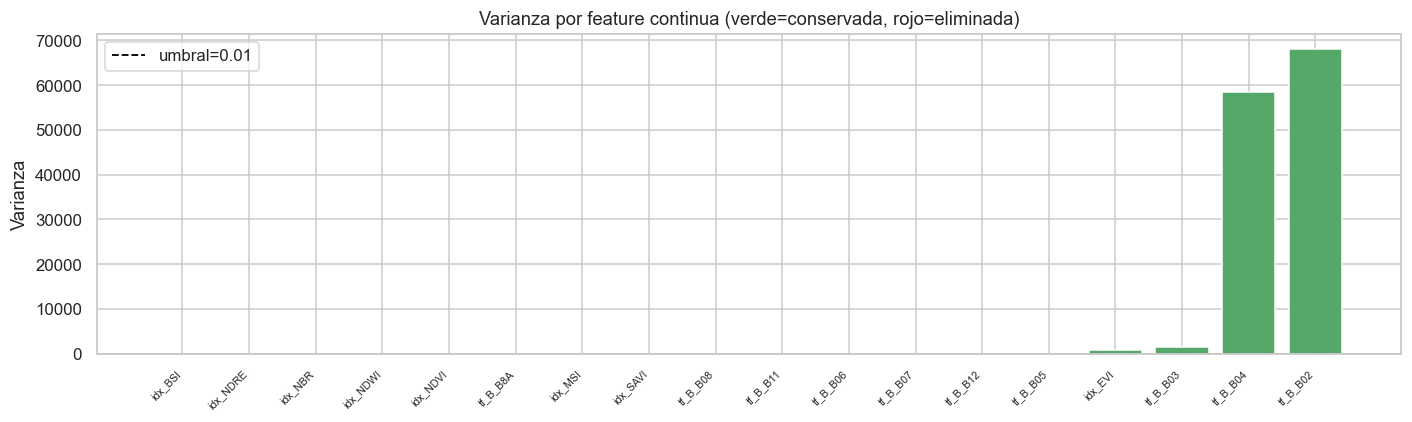

In [19]:
# ── 8.1 Umbral de varianza sobre features continuas ──────────────────────────
var_threshold = 0.01   # ajustable; equivale a ~10% de la varianza mínima esperada

continuous_fe_cols = trans_cols + index_cols
X_cont = df_fe.select(continuous_fe_cols).to_pandas().astype(float)

vt = VarianceThreshold(threshold=var_threshold)
vt.fit(X_cont)

variances   = pd.Series(vt.variances_, index=continuous_fe_cols).sort_values()
kept_mask   = vt.get_support()
kept_cols   = [c for c, k in zip(continuous_fe_cols, kept_mask) if k]
removed_cols= [c for c, k in zip(continuous_fe_cols, kept_mask) if not k]

print(f"Umbral de varianza: {var_threshold}")
print(f"Features continuas evaluadas: {len(continuous_fe_cols)}")
print(f"  ✓ Conservadas: {len(kept_cols)}")
print(f"  ✗ Eliminadas:  {len(removed_cols)}  → {removed_cols}")

fig, ax = plt.subplots(figsize=(13, 4))
colors_var = ["#C44E52" if not k else "#55A868" for k in kept_mask]
ax.bar(range(len(variances)), variances.values, color=[
    "#C44E52" if v < var_threshold else "#55A868" for v in variances.values
])
ax.axhline(var_threshold, color="black", ls="--", lw=1.2, label=f"umbral={var_threshold}")
ax.set_xticks(range(len(variances)))
ax.set_xticklabels(variances.index, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Varianza")
ax.set_title("Varianza por feature continua (verde=conservada, rojo=eliminada)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_OUT / "fe_06_variance_threshold.png", dpi=200, bbox_inches="tight")
plt.show()


### 8.2 Correlación de Pearson y Spearman

**Justificación**: Features altamente correlacionadas entre sí aportan información
redundante. Conservar ambas no mejora el modelo pero aumenta la colinealidad
(inestabilidad en modelos lineales, mayor varianza en coeficientes).

- **Pearson**: asume linealidad; adecuado para las bandas continuas transformadas.
- **Spearman**: basado en rangos; más robusto para relaciones monótonas no lineales.

Criterio: si |r| > 0.90 entre dos features, se elimina la que tenga menor
correlación con la variable objetivo (`class_id`).


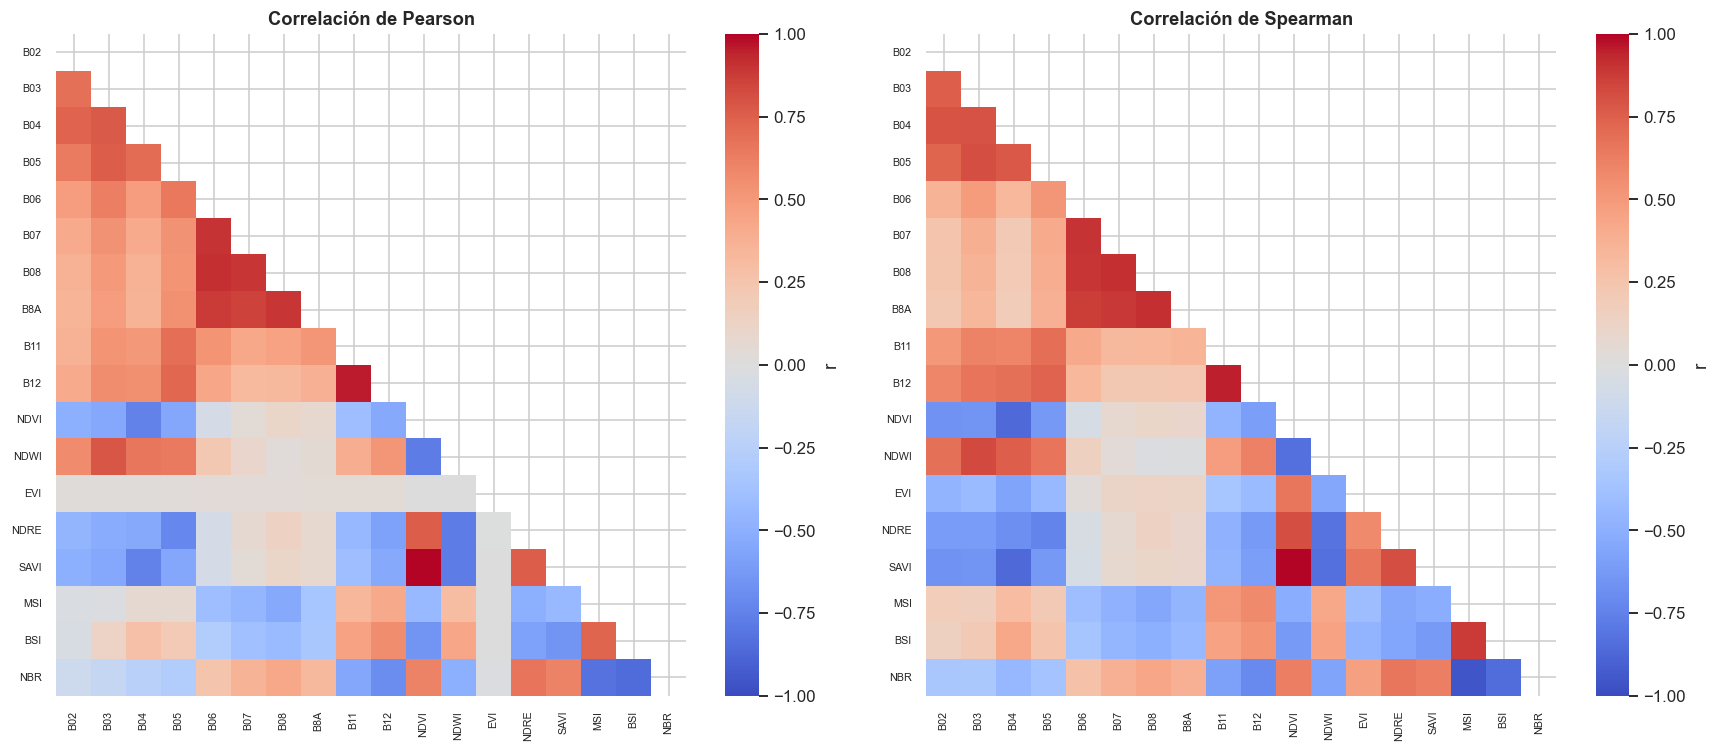

In [20]:
# ── 8.2a Matriz de correlación de Pearson ─────────────────────────────────────
X_kept = df_fe.select(kept_cols).to_pandas().astype(float)

corr_pearson  = X_kept.corr(method="pearson")
corr_spearman = X_kept.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, corr_mat, title in zip(
    axes,
    [corr_pearson, corr_spearman],
    ["Correlación de Pearson", "Correlación de Spearman"]
):
    mask = np.triu(np.ones_like(corr_mat, dtype=bool))
    sns.heatmap(
        corr_mat, mask=mask, cmap="coolwarm", center=0,
        vmin=-1, vmax=1, annot=False, ax=ax,
        xticklabels=[c.replace("tf_B_", "").replace("idx_", "") for c in kept_cols],
        yticklabels=[c.replace("tf_B_", "").replace("idx_", "") for c in kept_cols],
        cbar_kws={"label": "r"}
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.tick_params(labelsize=7)

fig.tight_layout()
fig.savefig(FIG_OUT / "fe_07_correlation_matrices.png", dpi=200, bbox_inches="tight")
plt.show()


In [21]:
# ── 8.2b Eliminación de features altamente correlacionadas (|r| > 0.90) ───────
CORR_THRESHOLD = 0.90

upper_triangle = corr_pearson.where(
    np.triu(np.ones(corr_pearson.shape, dtype=bool), k=1)
)
to_drop_corr = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col].abs() > CORR_THRESHOLD)
]

print(f"Umbral de correlación: |r| > {CORR_THRESHOLD}")
print(f"Features eliminadas por alta correlación ({len(to_drop_corr)}): {to_drop_corr}")

# Pares de alta correlación para reporte
high_corr_pairs = []
for col in upper_triangle.columns:
    correlated = upper_triangle[col][upper_triangle[col].abs() > CORR_THRESHOLD]
    for idx_r, val in correlated.items():
        high_corr_pairs.append({"feature_A": col, "feature_B": idx_r, "pearson_r": round(val, 4)})
if high_corr_pairs:
    display(pd.DataFrame(high_corr_pairs))
else:
    print("No se encontraron pares con |r| > 0.90")

final_cols_after_corr = [c for c in kept_cols if c not in to_drop_corr]
print(f"\nFeatures tras filtro de correlación: {len(final_cols_after_corr)}")


Umbral de correlación: |r| > 0.9
Features eliminadas por alta correlación (4): ['tf_B_B07', 'tf_B_B08', 'tf_B_B12', 'idx_SAVI']


,feature_A,feature_B,pearson_r
0,tf_B_B07,tf_B_B06,0.9057
1,tf_B_B08,tf_B_B06,0.9119
2,tf_B_B12,tf_B_B11,0.9557
3,idx_SAVI,idx_NDVI,1.0000



Features tras filtro de correlación: 14


### 8.3 Chi-Cuadrado

**Justificación**: El test χ² mide la dependencia entre una variable discreta
(bins) y la variable objetivo (clase de cultivo). Es adecuado para las features
discretizadas generadas en §4. Un valor alto de χ² indica que la distribución
de la feature varía significativamente entre clases → buena feature discriminativa.

**Requisito**: valores no negativos (enteros de bins) y etiquetas de clase disponibles.


Ranking Chi-cuadrado (features discretizadas vs class_id):


,feature,chi2,p_value,significativa (p<0.05)
9,bin_q_B_B12,105.875814,4.560403e-14,True
6,bin_q_B_B08,103.110192,1.458691e-13,True
7,bin_q_B_B8A,96.727670,2.086505e-12,True
8,bin_q_B_B11,91.502721,1.794837e-11,True
5,bin_q_B_B07,84.352897,3.267371e-10,True
2,bin_q_B_B04,83.718949,4.214888e-10,True
4,bin_q_B_B06,78.774324,3.021887e-09,True
1,bin_q_B_B03,72.623209,3.351976e-08,True
0,bin_q_B_B02,70.598909,7.311712e-08,True
3,bin_q_B_B05,68.943654,1.376911e-07,True


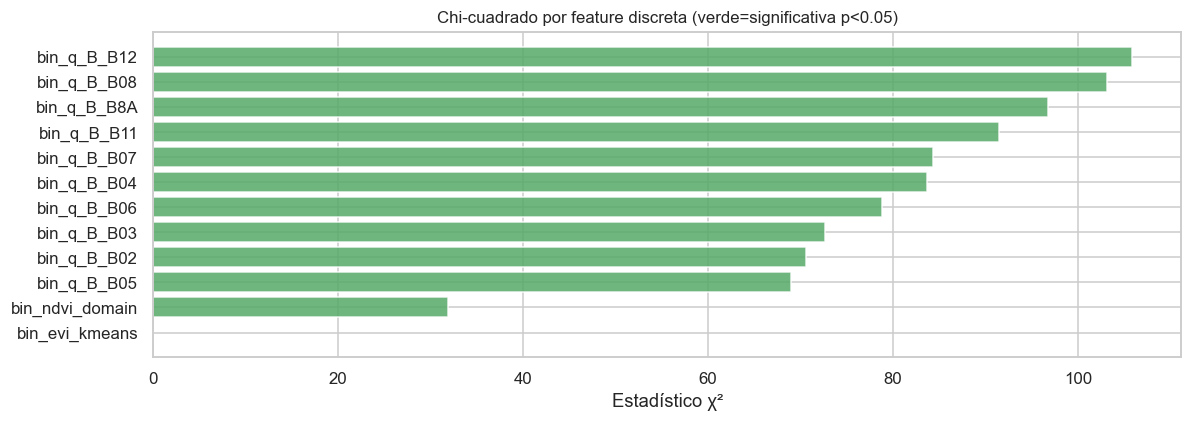

In [22]:
# ── 8.3 Chi-cuadrado sobre features discretizadas ────────────────────────────
if "class_id" in df_fe.columns:
    chi2_input_cols = bin_q_cols + ["bin_ndvi_domain", "bin_evi_kmeans"]
    chi2_input_cols = [c for c in chi2_input_cols if c in df_fe.columns]

    X_chi2 = df_fe.select(chi2_input_cols).to_pandas().astype(float)
    y_chi2 = df_fe["class_id"].to_numpy()

    chi2_scores, chi2_pvals = chi2(X_chi2, y_chi2)

    df_chi2 = pd.DataFrame({
        "feature":  chi2_input_cols,
        "chi2":     chi2_scores,
        "p_value":  chi2_pvals,
        "significativa (p<0.05)": chi2_pvals < 0.05,
    }).sort_values("chi2", ascending=False)

    print("Ranking Chi-cuadrado (features discretizadas vs class_id):")
    display(df_chi2)

    fig, ax = plt.subplots(figsize=(11, 4))
    colors_chi = ["#55A868" if p < 0.05 else "#C44E52" for p in df_chi2["p_value"]]
    ax.barh(df_chi2["feature"], df_chi2["chi2"], color=colors_chi, alpha=0.85)
    ax.set_xlabel("Estadístico χ²")
    ax.set_title("Chi-cuadrado por feature discreta (verde=significativa p<0.05)", fontsize=11)
    ax.invert_yaxis()
    fig.tight_layout()
    fig.savefig(FIG_OUT / "fe_08_chi2.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("'class_id' no disponible — se omite Chi-cuadrado")
    df_chi2 = pd.DataFrame()


### 8.4 ANOVA F-score

**Justificación**: ANOVA descompone la varianza de cada feature en varianza
*entre clases* (señal) y varianza *dentro de clase* (ruido). Un F alto indica
que la media de la feature difiere significativamente entre cultivos → buena
feature para clasificación. Se aplica sobre las features continuas transformadas.


Top-10 features por F-score ANOVA:


,feature,F_score,p_value,significativa (p<0.01)
13,idx_NBR,10.385345,1.266166e-29,True
12,idx_BSI,8.431247,4.686057e-23,True
11,idx_MSI,6.306650,5.776972e-16,True
7,idx_NDVI,5.549208,1.774927e-13,True
10,idx_NDRE,5.021038,9.129539e-12,True
5,tf_B_B8A,4.096523,7.697207e-09,True
8,idx_NDWI,3.903108,3.042572e-08,True
4,tf_B_B06,3.253427,2.714636e-06,True
6,tf_B_B11,2.907613,2.676924e-05,True
3,tf_B_B05,1.690602,3.148593e-02,False



Top-14 features seleccionadas por ANOVA F-score:
['idx_NBR', 'idx_BSI', 'idx_MSI', 'idx_NDVI', 'idx_NDRE', 'tf_B_B8A', 'idx_NDWI', 'tf_B_B06', 'tf_B_B11', 'tf_B_B05', 'tf_B_B03', 'tf_B_B04', 'tf_B_B02', 'idx_EVI']


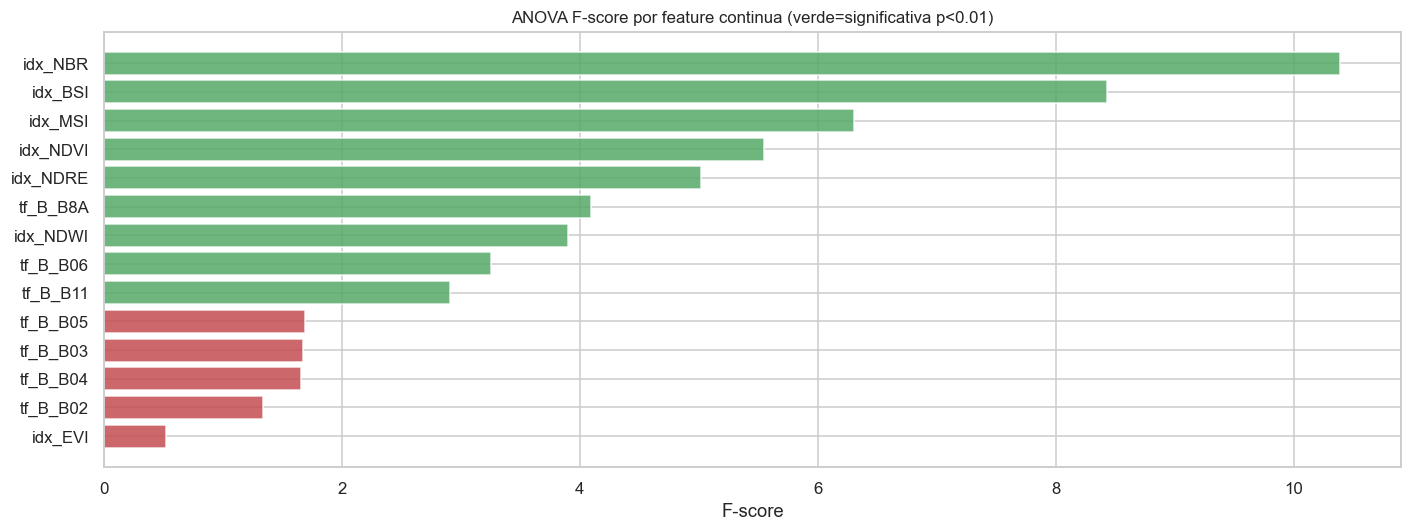

In [23]:
# ── 8.4 ANOVA F-score sobre features continuas ───────────────────────────────
if "class_id" in df_fe.columns:
    X_anova = df_fe.select(final_cols_after_corr).to_pandas().astype(float)
    y_anova = df_fe["class_id"].to_numpy()

    f_scores, f_pvals = f_classif(X_anova, y_anova)

    df_anova = pd.DataFrame({
        "feature":  final_cols_after_corr,
        "F_score":  f_scores,
        "p_value":  f_pvals,
        "significativa (p<0.01)": f_pvals < 0.01,
    }).sort_values("F_score", ascending=False)

    print(f"Top-10 features por F-score ANOVA:")
    display(df_anova.head(10))

    # Selección por umbral: top-K (K=15 o todas si menos)
    K_anova = min(15, len(df_anova))
    top_anova_cols = df_anova.head(K_anova)["feature"].tolist()
    print(f"\nTop-{K_anova} features seleccionadas por ANOVA F-score:")
    print(top_anova_cols)

    fig, ax = plt.subplots(figsize=(13, 5))
    colors_f = ["#55A868" if p < 0.01 else "#C44E52" for p in df_anova["p_value"]]
    ax.barh(df_anova["feature"], df_anova["F_score"], color=colors_f, alpha=0.85)
    ax.set_xlabel("F-score")
    ax.set_title("ANOVA F-score por feature continua (verde=significativa p<0.01)", fontsize=11)
    ax.invert_yaxis()
    fig.tight_layout()
    fig.savefig(FIG_OUT / "fe_09_anova_fscore.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("'class_id' no disponible — se omite ANOVA")
    top_anova_cols = final_cols_after_corr
    df_anova = pd.DataFrame()


### 8.5 Análisis de Componentes Principales (PCA)

**Justificación**: PCA proyecta el espacio de features al subespacio de máxima
varianza. Es adecuado cuando existe correlación entre features (demostrado en §8.2)
y se quiere reducir dimensionalidad sin perder información.

**Configuración**: se aplica PCA sobre las features escaladas (z-score) para que
la escala no domine la covarianza. Se selecciona el número de componentes que
explica ≥ 95% de la varianza acumulada.


Varianza explicada por componente:
  PC01: 0.6219  acumulado=0.6219
  PC02: 0.1711  acumulado=0.7931
  PC03: 0.1024  acumulado=0.8955
  PC04: 0.0298  acumulado=0.9253
  PC05: 0.0239  acumulado=0.9492
  PC06: 0.0190  acumulado=0.9682 ← 95%
  PC07: 0.0133  acumulado=0.9815
  PC08: 0.0094  acumulado=0.9909
  PC09: 0.0068  acumulado=0.9977
  PC10: 0.0023  acumulado=1.0000


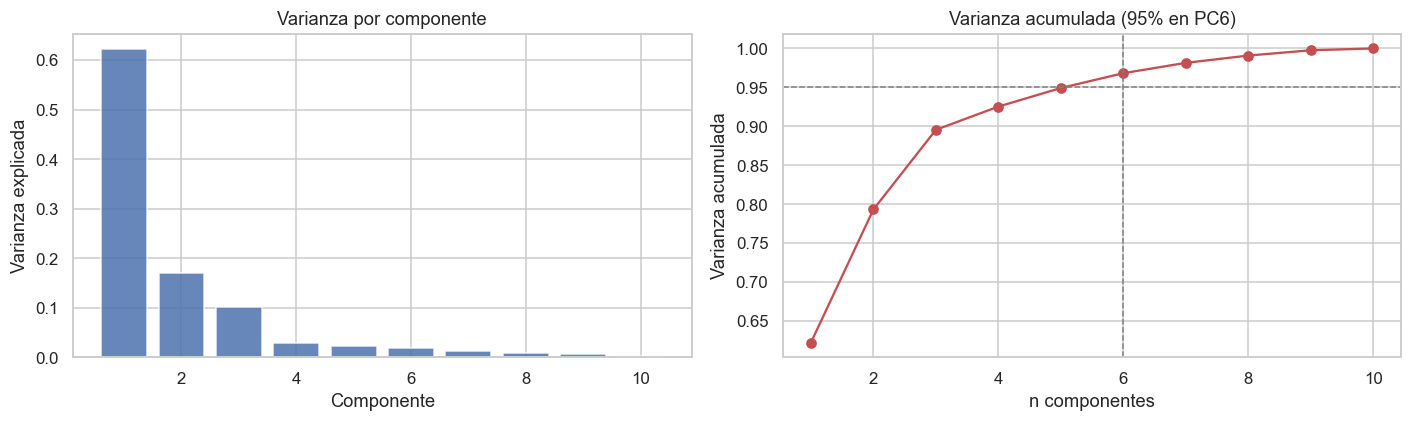

In [24]:
# ── 8.5a PCA — varianza explicada ─────────────────────────────────────────────
X_pca_input = df_fe.select(zscore_cols).to_pandas().dropna(axis=1).astype(float)
pca_full    = PCA(random_state=seed)
pca_full.fit(X_pca_input)

explained_var  = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
n_components_95 = int(np.searchsorted(cumulative_var, 0.95)) + 1

print(f"Varianza explicada por componente:")
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), 1):
    marker = " ← 95%" if i == n_components_95 else ""
    print(f"  PC{i:02d}: {ev:.4f}  acumulado={cv:.4f}{marker}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, len(explained_var)+1), explained_var, color="#4C72B0", alpha=0.85)
axes[0].set_xlabel("Componente")
axes[0].set_ylabel("Varianza explicada")
axes[0].set_title("Varianza por componente")

axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, marker="o", color="#C44E52")
axes[1].axhline(0.95, ls="--", color="gray", lw=1)
axes[1].axvline(n_components_95, ls="--", color="gray", lw=1)
axes[1].set_xlabel("n componentes")
axes[1].set_ylabel("Varianza acumulada")
axes[1].set_title(f"Varianza acumulada (95% en PC{n_components_95})")

fig.tight_layout()
fig.savefig(FIG_OUT / "fe_10_pca_variance.png", dpi=200, bbox_inches="tight")
plt.show()


PCA: 10 features → 6 componentes (96.8% varianza)


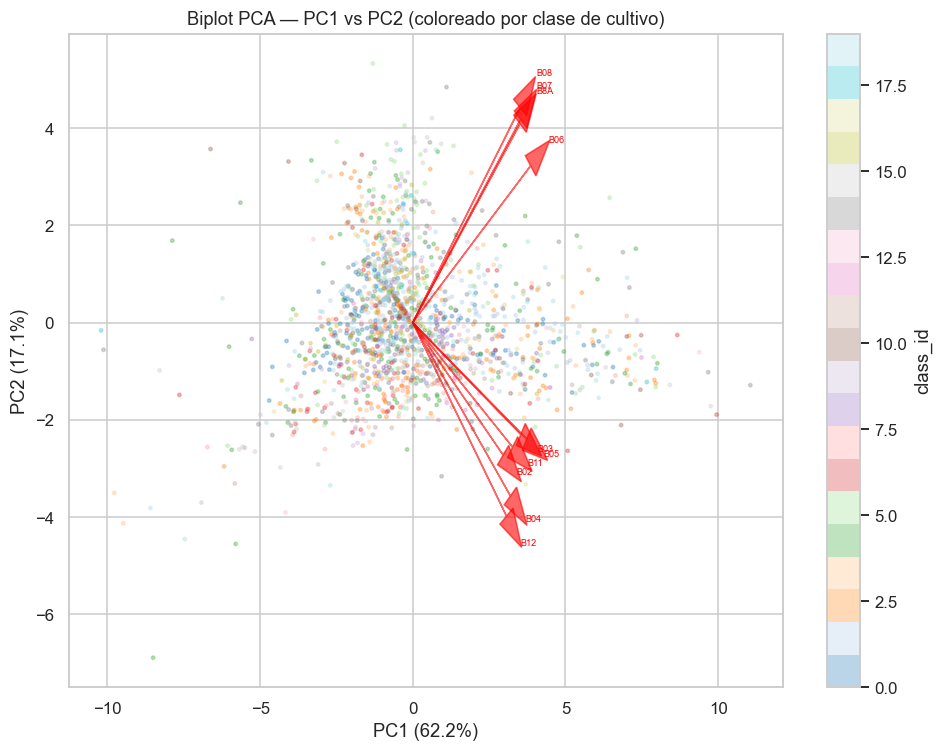

In [25]:
# ── 8.5b PCA — proyección y biplot ───────────────────────────────────────────
pca_final = PCA(n_components=n_components_95, random_state=seed)
X_pca     = pca_final.fit_transform(X_pca_input)
pca_cols  = [f"pca_{i+1}" for i in range(n_components_95)]

for j, col in enumerate(pca_cols):
    df_fe = df_fe.with_columns(pl.Series(col, X_pca[:, j]))

print(f"PCA: {X_pca_input.shape[1]} features → {n_components_95} componentes "
      f"({cumulative_var[n_components_95-1]*100:.1f}% varianza)")

# Biplot PC1 vs PC2 coloreado por clase
fig, ax = plt.subplots(figsize=(9, 7))
if "class_id" in df_fe.columns:
    classes  = df_fe["class_id"].to_numpy()
    scatter  = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=classes,
                          cmap="tab20", alpha=0.3, s=5, rasterized=True)
    plt.colorbar(scatter, ax=ax, label="class_id")
else:
    ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=5, rasterized=True)

# Vectores de carga (loadings)
loadings = pca_final.components_.T
scale    = np.abs(X_pca[:, :2]).max() / np.abs(loadings[:, :2]).max() * 0.4
feat_labels = [c.replace("sc_zscore_", "").replace("tf_B_", "") for c in X_pca_input.columns]
for i, (lx, ly) in enumerate(loadings[:, :2]):
    ax.arrow(0, 0, lx*scale, ly*scale, head_width=0.05*scale, color="red", alpha=0.6)
    ax.text(lx*scale*1.15, ly*scale*1.15, feat_labels[i], fontsize=6, color="red")

ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}%)")
ax.set_title("Biplot PCA — PC1 vs PC2 (coloreado por clase de cultivo)")
fig.tight_layout()
fig.savefig(FIG_OUT / "fe_11_pca_biplot.png", dpi=200, bbox_inches="tight")
plt.show()


### 8.6 Análisis Factorial (FA)

**Justificación**: A diferencia de PCA (que maximiza varianza total), el Análisis
Factorial asume que las correlaciones observadas entre las features se deben a
*factores latentes* subyacentes — en este dominio, los factores podrían corresponder
a grupos físicos como "vigor vegetativo", "contenido hídrico" o "suelo desnudo".

FA descompone la covarianza en varianza compartida (comunalidades) y varianza
específica (unicidad), siendo más interpretable cuando el objetivo es entender
la estructura del espacio de features.


Análisis Factorial: 5 factores

Matriz de cargas (|loading| > 0.3 = asociación relevante):


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5
B02,-0.500,-0.177,-0.604,-0.094,-0.005
B03,-0.669,-0.196,-0.526,0.017,-0.009
B04,-0.616,-0.074,-0.654,-0.212,0.093
B05,-0.806,-0.106,-0.373,0.128,-0.223
B06,-0.707,-0.659,-0.029,0.115,0.041
B07,-0.603,-0.717,0.025,0.044,0.088
B08,-0.619,-0.720,0.102,0.011,0.038
B8A,-0.661,-0.660,0.178,-0.146,-0.106
B11,-0.957,0.211,0.130,-0.050,0.009
B12,-0.928,0.344,-0.016,0.046,0.005


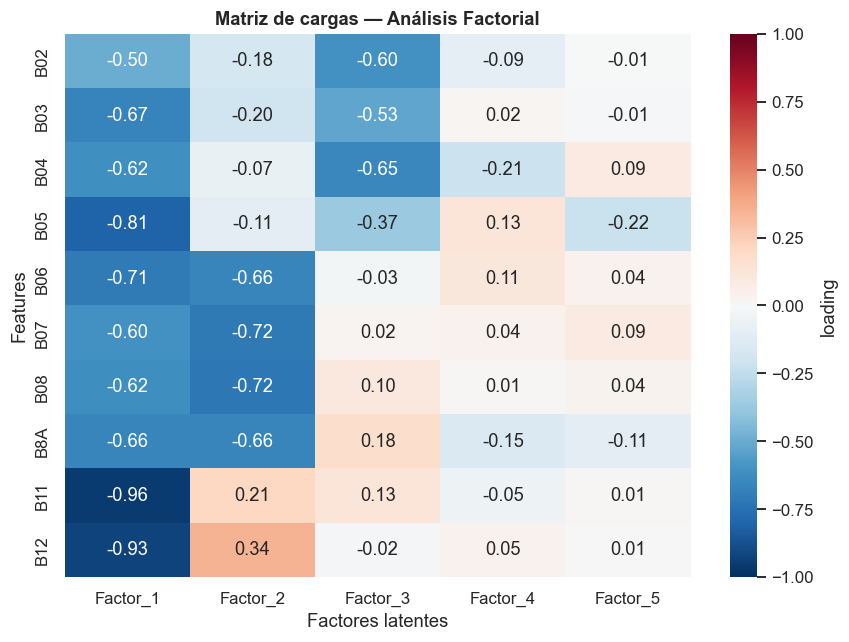


Unicidad por feature (varianza no explicada por factores):


,uniqueness
B02,0.344838
B03,0.236534
B05,0.133997
B04,0.133439
B07,0.112968
B08,0.086135
B8A,0.064276
B06,0.050551
B11,0.020332
B12,0.018904


In [26]:
# ── 8.6 Análisis Factorial ────────────────────────────────────────────────────
n_factors = min(5, X_pca_input.shape[1])   # máximo 5 factores
fa = FactorAnalysis(n_components=n_factors, random_state=seed, max_iter=1000)
X_fa = fa.fit_transform(X_pca_input)

fa_cols = [f"fa_{i+1}" for i in range(n_factors)]
for j, col in enumerate(fa_cols):
    df_fe = df_fe.with_columns(pl.Series(col, X_fa[:, j]))

# Matriz de cargas (loadings)
loadings_fa = pd.DataFrame(
    fa.components_.T,
    index=feat_labels,
    columns=[f"Factor_{i+1}" for i in range(n_factors)]
)
print(f"Análisis Factorial: {n_factors} factores")
print("\nMatriz de cargas (|loading| > 0.3 = asociación relevante):")
display(loadings_fa.style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1).format("{:.3f}"))

# Heatmap de cargas
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(loadings_fa, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", ax=ax, cbar_kws={"label": "loading"})
ax.set_title("Matriz de cargas — Análisis Factorial", fontsize=12, fontweight="bold")
ax.set_xlabel("Factores latentes")
ax.set_ylabel("Features")
fig.tight_layout()
fig.savefig(FIG_OUT / "fe_12_factor_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

# Unicidad (varianza no explicada por factores)
uniqueness = pd.Series(fa.noise_variance_, index=feat_labels).sort_values(ascending=False)
print("\nUnicidad por feature (varianza no explicada por factores):")
display(uniqueness.to_frame("uniqueness").style.bar(color="steelblue"))


## 9. Consolidación del Feature Set y Exportación

Se construyen **tres versiones** del feature set para diferentes escenarios de modelado:

| Versión | Descripción | Uso recomendado |
|---|---|---|
| `full` | Todas las features generadas | Análisis exploratorio, modelos basados en árboles |
| `selected` | Solo features seleccionadas por varianza + correlación + ANOVA | Modelos lineales, SVM |
| `pca` | Componentes principales (95% varianza) + OHE | Redes neuronales, clustering |


In [27]:
# ── 9a. Feature sets finales ──────────────────────────────────────────────────
# Version 1: FULL — todas las features numéricas generadas
full_cols = (
    band_cols + index_cols + bin_q_cols +
    ["bin_ndvi_domain", "bin_evi_kmeans"] +
    trans_cols + zscore_cols + ohe_cols
)
full_cols = [c for c in full_cols if c in df_fe.columns]

# Version 2: SELECTED — filtrado por varianza + correlación + top ANOVA
selected_cols = [c for c in top_anova_cols if c in df_fe.columns] +                 [c for c in ohe_cols if c in df_fe.columns]

# Version 3: PCA — componentes + OHE
pca_feature_cols = pca_cols + [c for c in ohe_cols if c in df_fe.columns]
pca_feature_cols = [c for c in pca_feature_cols if c in df_fe.columns]

print("=== Feature Sets Finales ===")
print(f"  full:     {len(full_cols):3d} features")
print(f"  selected: {len(selected_cols):3d} features")
print(f"  pca:      {len(pca_feature_cols):3d} features (incl. OHE)")

# Mostrar resumen estadístico del set seleccionado
display(df_fe.select(selected_cols[:8]).describe())


=== Feature Sets Finales ===
  full:      70 features
  selected:  34 features
  pca:       26 features (incl. OHE)


statistic,idx_NBR,idx_BSI,idx_MSI,idx_NDVI,idx_NDRE,tf_B_B8A,idx_NDWI,tf_B_B06
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1618.0,1618.0,1618.0,1618.0,1618.0,1618.0,1618.0,1618.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.314611,-0.057648,0.816151,0.425442,0.311713,8.082926,-0.454781,7.876796
"""std""",0.209402,0.169734,0.373445,0.253667,0.191073,0.362735,0.216613,0.394543
"""min""",-0.724566,-0.73559,0.045243,-0.6424,-0.649012,6.242223,-1.028445,5.204007
"""25%""",0.184278,-0.14257,0.62638,0.241676,0.176823,7.893124,-0.610731,7.677864
"""50%""",0.310892,-0.047572,0.781638,0.409419,0.306587,8.088022,-0.477114,7.851432
"""75%""",0.44029,0.048739,0.963158,0.600245,0.435618,8.282736,-0.325755,8.055634
"""max""",0.955334,0.630956,9.373874,1.705327,0.944792,9.2534,0.551026,9.237956


In [28]:
# ── 9b. Exportación a Parquet ─────────────────────────────────────────────────
# Parquet: columnar, comprimido, compatible con Polars/Pandas/Spark.
meta_cols = [c for c in ["class_id", "class_name", "date"] if c in df_fe.columns]

for version, cols in [
    ("full",     full_cols),
    ("selected", selected_cols),
    ("pca",      pca_feature_cols),
]:
    export_cols = meta_cols + cols
    export_cols = [c for c in export_cols if c in df_fe.columns]
    path = EXPORT / f"sentinel2_features_{version}.parquet"
    df_fe.select(export_cols).write_parquet(path, compression="zstd")
    size_mb = path.stat().st_size / 1_048_576
    print(f"  ✓ {version:10s} → {path.name}  ({len(export_cols)} cols, {size_mb:.1f} MB)")

print("\nExportación completada.")


  ✓ full       → sentinel2_features_full.parquet  (73 cols, 0.4 MB)
  ✓ selected   → sentinel2_features_selected.parquet  (37 cols, 0.2 MB)
  ✓ pca        → sentinel2_features_pca.parquet  (29 cols, 0.1 MB)

Exportación completada.


## 10. Resumen y Próximos Pasos

### Decisiones tomadas y justificación

| Etapa | Decisión | Justificación |
|---|---|---|
| Máscara de calidad | Clip P99.5 antes de cualquier FE | Evita que nubes residuales contaminen todas las features derivadas |
| Índices espectrales | 8 índices (NDVI, NDWI, EVI, NDRE, SAVI, MSI, BSI, NBR) | Conocimiento de dominio; reducen el espacio de hipótesis |
| Discretización | Quantile (bandas) + dominio (NDVI) + kmeans (EVI) | NDVI tiene umbrales físicos conocidos; quantile garantiza bins equipoblados para χ² |
| Transformación | log1p (bandas positivas) + Yeo-Johnson (con negativos) | EDA confirmó sesgo positivo en todas las bandas; elección automática por signo del mínimo |
| Escalamiento | Z-score (default) + Min-Max + Robust (comparativo) | Z-score requerido para PCA y modelos lineales; Robust para análisis con outliers |
| Codificación | One-Hot (cultivos, variable nominal) + Ordinal (estación, variable con orden) | Evita que el modelo infiera distancias ordinales entre cultivos |
| Umbral varianza | var > 0.01 | Elimina features constantes o quasi-constantes sin valor discriminativo |
| Correlación | |r| > 0.90 → eliminar | Reduce colinealidad sin sacrificar información |
| Chi-cuadrado | Ranking sobre bins, p < 0.05 | Selección supervisada de bins más informativos |
| ANOVA F-score | Top-15 features continuas | Selección supervisada basada en separación entre clases |
| PCA | n componentes para 95% varianza | Eliminación de redundancia residual tras selección |
| Análisis Factorial | 5 factores latentes | Interpretación de grupos de features (dominio físico) |

### Próximos pasos

1. **Entrenamiento de modelos baseline** con los 3 feature sets exportados.
2. **Validación cruzada estratificada** por clase de cultivo (imbalance documentado en EDA).
3. **Importancia de features** con Random Forest / XGBoost sobre el set `full`.
4. **Transferencia a Italia**: aplicar el mismo pipeline FE sobre `df_gee` con las transformaciones ajustadas en PASTIS-R (Francia).
